# AtmoResponse walkthrough

AtmoResponse walks Planet's open Tanager catalog, resolves an external aerosol
optical depth for a scene from AERONET, VIIRS, GOES, or MERRA-2, and measures how far
a reflectance algorithm's output moves when the atmospheric correction assumed the
wrong aerosol optical depth. It works for any algorithm the user supplies.

It answers two questions, both from a precomputed look-up table of 6S
atmospheric-correction coefficients rather than a live radiative-transfer run:

- **Potential Sensitivity.** Take a few representative pixels and sweep the assumed
  aerosol optical depth across a plausible range. How much does the output swing? This
  is a property of the algorithm.
- **Realized Sensitivity.** Take every usable pixel in the scene, run the algorithm
  twice, once at the aerosol optical depth Planet's pipeline actually used and once at
  an independent reference value, and difference the two. This is a property of the
  scene as it was delivered.

## The one call

Every example below reduces to this:

```python
result = sensitivity.run_tanager(
    scene_id, aoi, mask, band_targets_nm, reference_aod, aero_profile,
    algorithm=my_algorithm, data_dir=DATA_DIR, lut=LUT_STORE_TANAGER,
)
```

The user brings five things: a scene and an area of interest, a mask that picks the
pixels the algorithm is meant for, the algorithm, an independent reference aerosol
optical depth, and an aerosol model. Section 3 covers where the reference value comes
from and section 4 covers the aerosol model. The mask names only the analysis target
(open water, vegetation, bare rock). `masks.admissible` wraps it with the sensor's own
cloud, cirrus, and nodata screen, the look-up-table AOD-coverage check, and the
finite-radiance check, so those never appear in a section.

## 1. Setup

Install with `pip install "atmoresponse[notebook]"`. Every scene downloads once on
first use and is stored under `ATMORESPONSE_DATA`. The Tanager look-up table is a
separate download of about 240 MB, kept in the same place.

In [1]:
import datetime as dt
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import atmoresponse
from atmoresponse import masks, plotting, sensitivity, tanager_catalog, tanager_data
from atmoresponse.aod import AodQuery, AodSource, resolve_aod
from atmoresponse.downloads import download_lut
from atmoresponse.recipes import as_algorithm
from atmoresponse.recipes.agriculture import canopy_chlorophyll_rsi
from atmoresponse.recipes.cdom import cdom_absorption
from atmoresponse.recipes.cyanobacteria import cyanobacteria_index
from atmoresponse.recipes.mineral import aloh_2200_depth
from atmoresponse.recipes.wildfire_sam import (
    load_palisades_fire_perimeter,
    load_wildfire_sam_library,
    prepare_wildfire_sam,
)

DATA_DIR = Path(os.environ.get("ATMORESPONSE_DATA", "~/atmoresponse_data")).expanduser()
DATA_DIR.mkdir(parents=True, exist_ok=True)

LUT_STORE_TANAGER = download_lut("tanager", data_dir=DATA_DIR)  # idempotent, reuses the cached copy

print("atmoresponse", atmoresponse.__version__)
print("data :", DATA_DIR)
print("LUT   :", LUT_STORE_TANAGER)

atmoresponse 0.1.0
data : ~/atmoresponse_data
LUT   : ~/atmoresponse_data/lut/lut_store_tanager


## 2. Finding scenes in Planet's catalog

The Tanager open catalog is a static STAC catalog. No account or API key is needed.
`search_scenes` filters it by bounding box, time window, cloud cover, or collection.
Here is a search over the Malibu coast, the January 2025 wildfire scene used in
Walkthrough B (Section 6), for the first months of 2025.

In [2]:
malibu_scenes = tanager_catalog.search_scenes(
    tanager_catalog.SceneQuery(
        bbox=(-118.95, 33.90, -118.60, 34.15),
        start=dt.datetime(2025, 1, 1, tzinfo=dt.timezone.utc),
        end=dt.datetime(2025, 4, 1, tzinfo=dt.timezone.utc),
    )
)
for scene in malibu_scenes:
    print(scene.scene_id, scene.acquired.date(), scene.collections)

20250123_185518_92_4001 2025-01-23 ('fire', 'natural-lands')


The five examples below sit in five different places, so rather than search five
times the walkthrough does one wider search and reuses the records. `fetch_scene`
takes those records and downloads the surface reflectance and radiance for a scene on
first use.

In [3]:
scene_records = tanager_catalog.search_scenes(
    tanager_catalog.SceneQuery(
        start=dt.datetime(2025, 1, 1, tzinfo=dt.timezone.utc),
        end=dt.datetime(2025, 8, 31, tzinfo=dt.timezone.utc),
    )
)
print(len(scene_records), "scenes in the window")

117 scenes in the window


## 3. The reference aerosol optical depth

Realized Sensitivity needs an external aerosol optical depth at the scene's place and
time, to compare against the value Planet's pipeline used. AtmoResponse resolves one
from four sources with different standing: AERONET sun photometers are a direct ground
measurement, VIIRS and GOES are satellite retrievals, and MERRA-2 is a reanalysis that
assimilates AERONET and MODIS, so it is a spatial extrapolation rather than an
independent value. `resolve_aod` prefers a nearby AERONET station and falls back
through the others by distance and time offset.

AERONET is public, so the quick live check below source-limits the resolver to
AERONET and avoids credentialed downloads:

In [4]:
demo_reference = resolve_aod(
    AodQuery(latitude=34.05, longitude=-118.70, when=dt.datetime(2025, 1, 23, 18, 55)),
    sources=(AodSource.AERONET,),
)
print(demo_reference)

AodEstimate(value=0.040741090617555015, source=<AodSource.AERONET: 'aeronet'>, independence='measurement', distance_km=51.14020058497209, dt_minutes=0.25, detail='site MISR-JPL')


The full built-in resolver can also query GOES, VIIRS, and MERRA-2. GOES is public.
VIIRS and MERRA-2 additionally need NASA Earthdata credentials and the live-data
dependencies installed. Each example below states a recorded reference value and where
it came from, which keeps the walkthrough reproducible offline once the scenes are
downloaded. `references` lists every estimate gathered for that scene as `(source, value,
detail)`, and the Potential Sensitivity plot draws all of them.

## 4. The aerosol model

`aero_profile` selects one of the four 6S aerosol models: `Maritime`, `Continental`,
`Urban`, or `Desert`. Neither the delivered Tanager product nor a single aerosol
optical depth number names the model, so it is an analyst choice from the scene's
geography: Maritime over the coastal ocean, Continental over inland vegetated land,
Desert over an arid basin. Because Realized Sensitivity differences two runs at one
fixed model, a wrong model choice partly cancels rather than propagating in full.

## 5. Walkthrough A, a continuous output: canopy chlorophyll near Rajanpur, Pakistan

The scene covers irrigated winter cropland in the Rajanpur district of Punjab,
Pakistan. The algorithm is the Inoue et al. (2016) red-edge ratio `R815 / R704`, a
proxy for canopy chlorophyll. The question: over a real farmland scene, how much of
the field-to-field spread in that ratio is real crop variation, and how much is just
the aerosol assumption?

The analysis target is `masks.tanager_vegetation`, a canopy-presence screen
(soil-adjusted vegetation index and a Dawson and Curran red edge position, which must
agree) with no dependence on the ratio being tested.

In [5]:
rsi_scene_id = "20250114_062056_92_4001"
rsi_aoi = (0, 1025, 0, 846)                 # the cultivated block, row0, row1, col0, col1
rsi_aero_profile = "Continental"            # inland agricultural plain
rsi_band_targets_nm = [704.0, 815.0]
rsi_reference_aod = 0.5363                  # MERRA-2, 26 km and 9 minutes off, a dust day
rsi_references = [
    ("merra2", 0.5363, "primary, 26 km, 9 min, assimilated"),
    ("viirs", 1.3630, "1 km, 57 min, measurement, unreliable over bright desert soil"),
]
rsi_mask = masks.admissible(rsi_scene_id, rsi_band_targets_nm, masks.tanager_vegetation, data_dir=DATA_DIR)

**The run.** One call fetches the scene, applies the mask, and evaluates the algorithm
at every admissible pixel at both aerosol optical depths. It returns the Potential
Sensitivity curves, the Realized Sensitivity map, and enough to replot either.

`extra_curve_aod` takes the alternate reference values from `rsi_references` so the
Potential Sensitivity curve is sampled and marked at each one, showing on the plot
where every source would land.

atmoresponse/lut.py:1072: RuntimeWarning: LUT has only CWV=1.0 populated for aerosol 'Continental', holding requested CWV at that level rather than interpolating a missing bracket.
  c, clamped = lookup_spectrum_batch(sun_z, view_z, raa, aero_profile, cwv_g_cm2, ozone,


atmosphere fraction: 0.09859906661145722 | reliable: True | coverage: 0.9092947190061971


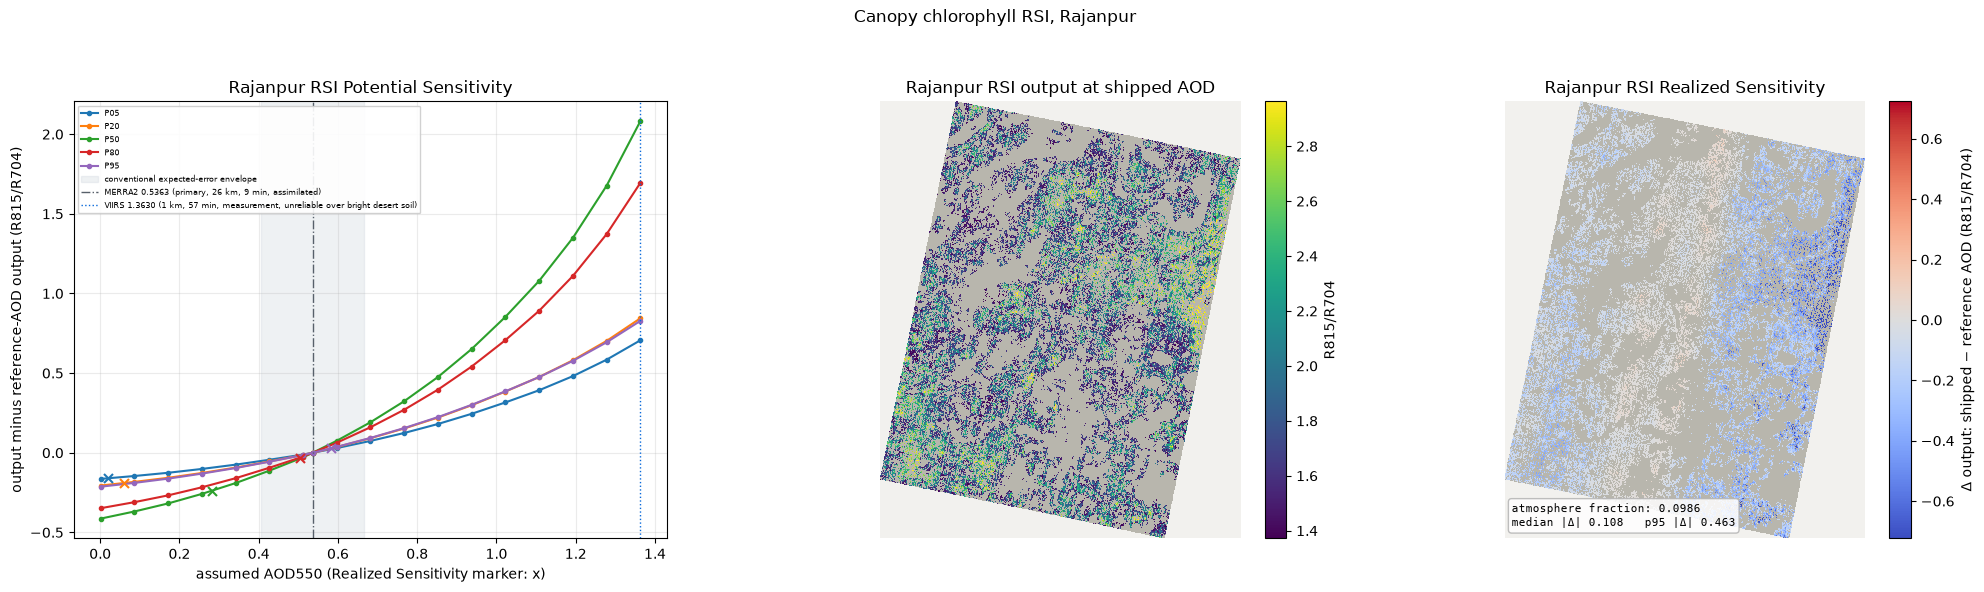

In [6]:
tanager_data.fetch_scene(rsi_scene_id, data_dir=DATA_DIR, records=scene_records)
result_rsi = sensitivity.run_tanager(
    rsi_scene_id, rsi_aoi, rsi_mask, rsi_band_targets_nm,
    rsi_reference_aod, rsi_aero_profile,
    algorithm=as_algorithm(canopy_chlorophyll_rsi),
    extra_curve_aod=[v for _s, v, _d in rsi_references],
    unit="R815/R704", algorithm_name="Rajanpur RSI",
    data_dir=DATA_DIR, lut=LUT_STORE_TANAGER,
)
vf_rsi = sensitivity.variance_fraction(result_rsi.at_reference, result_rsi.delta)
print("atmosphere fraction:", vf_rsi.atmosphere_fraction,
      "| reliable:", vf_rsi.reliable, "| coverage:", vf_rsi.coverage)
plotting.sensitivity_figure(result_rsi, references=rsi_references,
                            unit="R815/R704", title="Canopy chlorophyll RSI, Rajanpur")
plt.show()

## 6. Walkthrough B, a classifier: wildfire ash and char near Malibu, California

This scene was acquired days after the January 2025 fires on the coast west of Los
Angeles. The algorithm is a spectral angle mapper against a fixed library of ash,
char, vegetation, and soil endmembers. For a classifier the sensitivity question is
not how far a number moves but whether pixels cross a decision boundary: does the
aerosol assumption flip a pixel between burned and not burned?

### The endmember library

`load_wildfire_sam_library` returns a bundled 400 to 1300 nm library of 28 spectra,
14 burned and 14 unburned, drawn from the USGS spectral library (Clark et al. 2007)
and the SAFARI 2000 fire-residue measurements (Landmann and Roy 2004). It was built by
class quota with an angular farthest-first fill so the rows span each class rather
than clustering. Its `group_labels` collapse the 28 rows to burned versus not burned,
so only a flip across that line counts as a class change.

Load the library once. Its `group_labels` map each of the 28 endmember labels to
`burned` or `not burned`. The run uses the scene's own native Tanager bands over the
library's 400 to 1300 nm range, and `prepare_wildfire_sam` resamples the endmembers
onto that grid.

In [7]:
wildfire_library = load_wildfire_sam_library()
sam_group_labels = dict(zip(wildfire_library.labels, wildfire_library.group_labels))
print("library:", len(wildfire_library.reflectance), "spectra,",
      f"{wildfire_library.wavelengths_nm[0]:.0f}-{wildfire_library.wavelengths_nm[-1]:.0f} nm")
print("groups :", sorted(set(wildfire_library.group_labels)))

library: 28 spectra, 400-1300 nm
groups : ['burned', 'unburned']


### The scene and parameters

The block below fixes the scene, the AOI over the fire-affected coast, the Maritime
aerosol model for ocean-influenced coastal air, the VIIRS reference aerosol optical
depth, and the two nearby AERONET estimates for the Potential Sensitivity plot. The
analysis target is `masks.tanager_land`, non-water pixels only. `band_centers_nm`
needs the scene on disk, so the fetch happens here.

In [8]:
sam_scene_id = "20250123_185518_92_4001"
sam_aoi = (225, 605, 365, 957)             # the fire-affected block
sam_aero_profile = "Maritime"             # coastal, ocean-influenced air
sam_reference_aod = 0.0280                 # VIIRS, 11 km and 47 minutes off
sam_references = [
    ("viirs", 0.0280, "primary, 11 km, 47 min, measurement"),
    ("aeronet", 0.0420, "MISR-JPL, 52 km, same hour"),
    ("aeronet", 0.0320, "CalTech, 54 km, same hour"),
]
tanager_data.fetch_scene(sam_scene_id, data_dir=DATA_DIR, records=scene_records)
sam_band_targets_nm = tanager_data.band_centers_nm(sam_scene_id, DATA_DIR, lo=400.0, hi=1300.0)
sam_mask = masks.admissible(sam_scene_id, sam_band_targets_nm, masks.tanager_land, data_dir=DATA_DIR)

**The run.** `fit=` builds the classifier once the run knows the scene's actual band
grid, so the library is resampled onto exactly the bands the run reads. `group_labels`
tells the engine which label changes are real class flips. `scoring_region` is the
bundled Palisades fire perimeter (WFIGS): it outlines the burn on the maps and splits
the flip fraction into whole scene, inside, and outside.

atmoresponse/lut.py:930: RuntimeWarning: cwv=0.36480826139450073 is outside the LUT's tabulated range, held at the nearest node 1.0. clamp=True was requested.
  cwv_lo, cwv_hi, cwv_w, cwv_oor = _axis_spec_batch(axes, "cwv", cwv, cwv_pairs, clamp=clamp)


flip fraction  all 0.0418  in 0.0589  out 0.0244


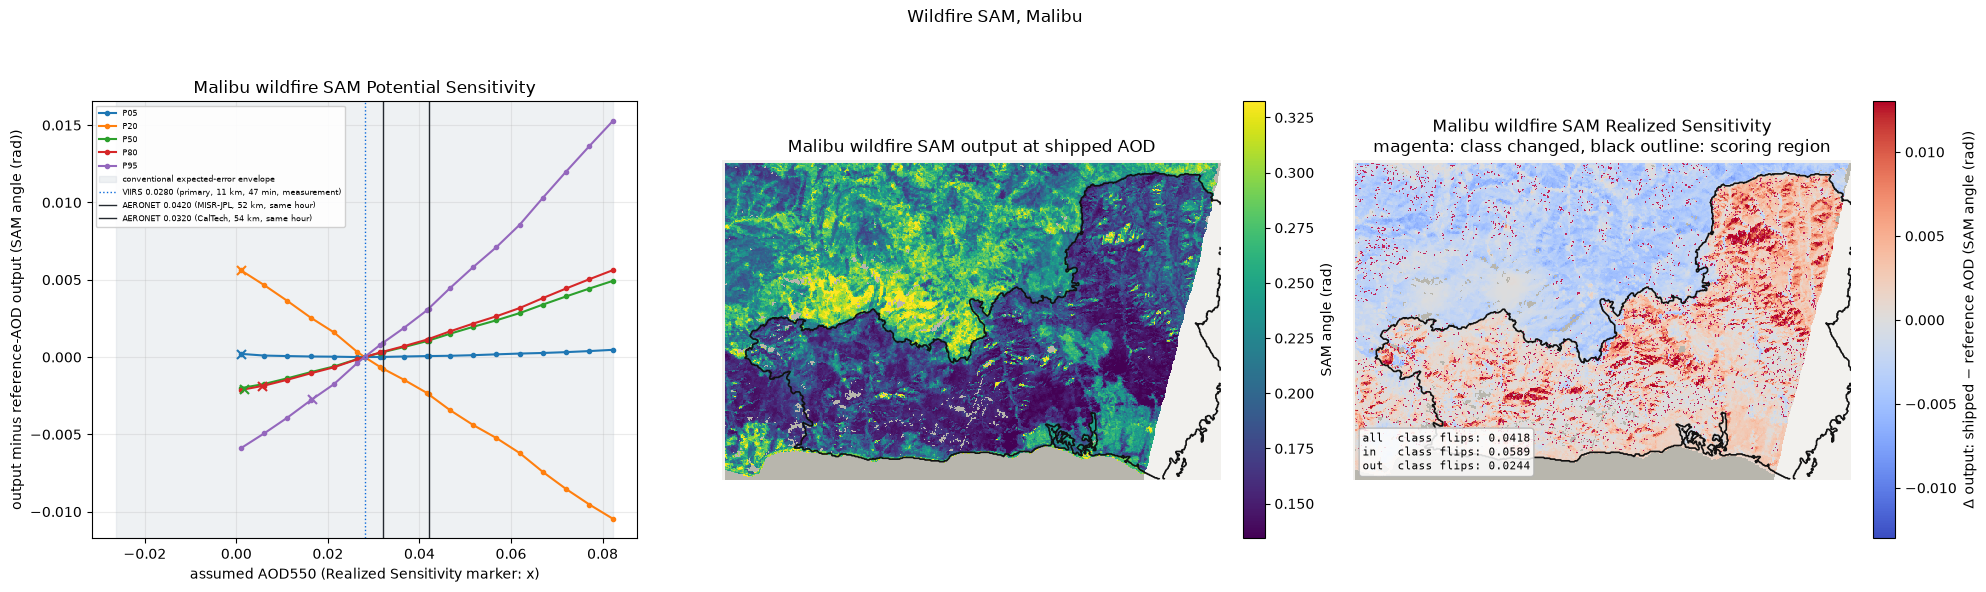

In [9]:
sam_perimeter = load_palisades_fire_perimeter()
result_sam = sensitivity.run_tanager(
    sam_scene_id, sam_aoi, sam_mask, sam_band_targets_nm,
    sam_reference_aod, sam_aero_profile,
    fit=lambda wl, _radiance: prepare_wildfire_sam(wl, wildfire_library),
    group_labels=sam_group_labels,
    extra_curve_aod=[v for _s, v, _d in sam_references],
    unit="SAM angle (rad)", algorithm_name="Malibu wildfire SAM",
    data_dir=DATA_DIR, lut=LUT_STORE_TANAGER,
)
sam_flip_fraction = float(result_sam.class_changed.mean())
sam_flip_inside = float(result_sam.scored(sam_perimeter).class_changed.mean())
sam_flip_outside = float(result_sam.scored(~sam_perimeter).class_changed.mean())
print(f"flip fraction  all {sam_flip_fraction:.4f}  in {sam_flip_inside:.4f}  out {sam_flip_outside:.4f}")
plotting.sensitivity_figure(result_sam, references=sam_references,
                            unit="SAM angle (rad)", title="Wildfire SAM, Malibu",
                            scoring_region=sam_perimeter)
plt.show()

## 7. A narrow-band water index: cyanobacteria on Lake Ontario

The Wynne and NOAA cyanobacteria index is a three-band difference around 620, 665, and
681 nm over open water. Because it differences nearby bands, an error that shifts the
whole spectrum tends to cancel. This is the case where Realized Sensitivity should
come out near zero.

`node_only=True` is set here and only here: the index is read at the look-up table's
tabulated aerosol optical depth nodes rather than interpolated between them, because
the band differencing is small enough that interpolation error would dominate it.

In [10]:
ci_scene_id = "20250704_165204_61_4001"
ci_aoi = (0, 746, 0, 842)
ci_aero_profile = "Continental"
ci_band_targets_nm = [620.0, 665.0, 681.0, 709.0]
ci_reference_aod = 0.2798                   # GOES, 1 km and 2 minutes off
ci_references = [
    ("goes", 0.2798, "primary, 1 km, 2 min, measurement"),
    ("viirs", 0.2930, "34 km, 38 min, measurement"),
    ("merra2", 0.1256, "27 km, 22 min, assimilated"),
]
ci_mask = masks.admissible(ci_scene_id, ci_band_targets_nm, masks.tanager_water, data_dir=DATA_DIR)

**The run.** `node_only=True` reads the index at the look-up table's tabulated aerosol
optical depth nodes rather than interpolating between them.

atmosphere fraction: 0.00334371739727399 | reliable: True | coverage: 0.9395083870186886


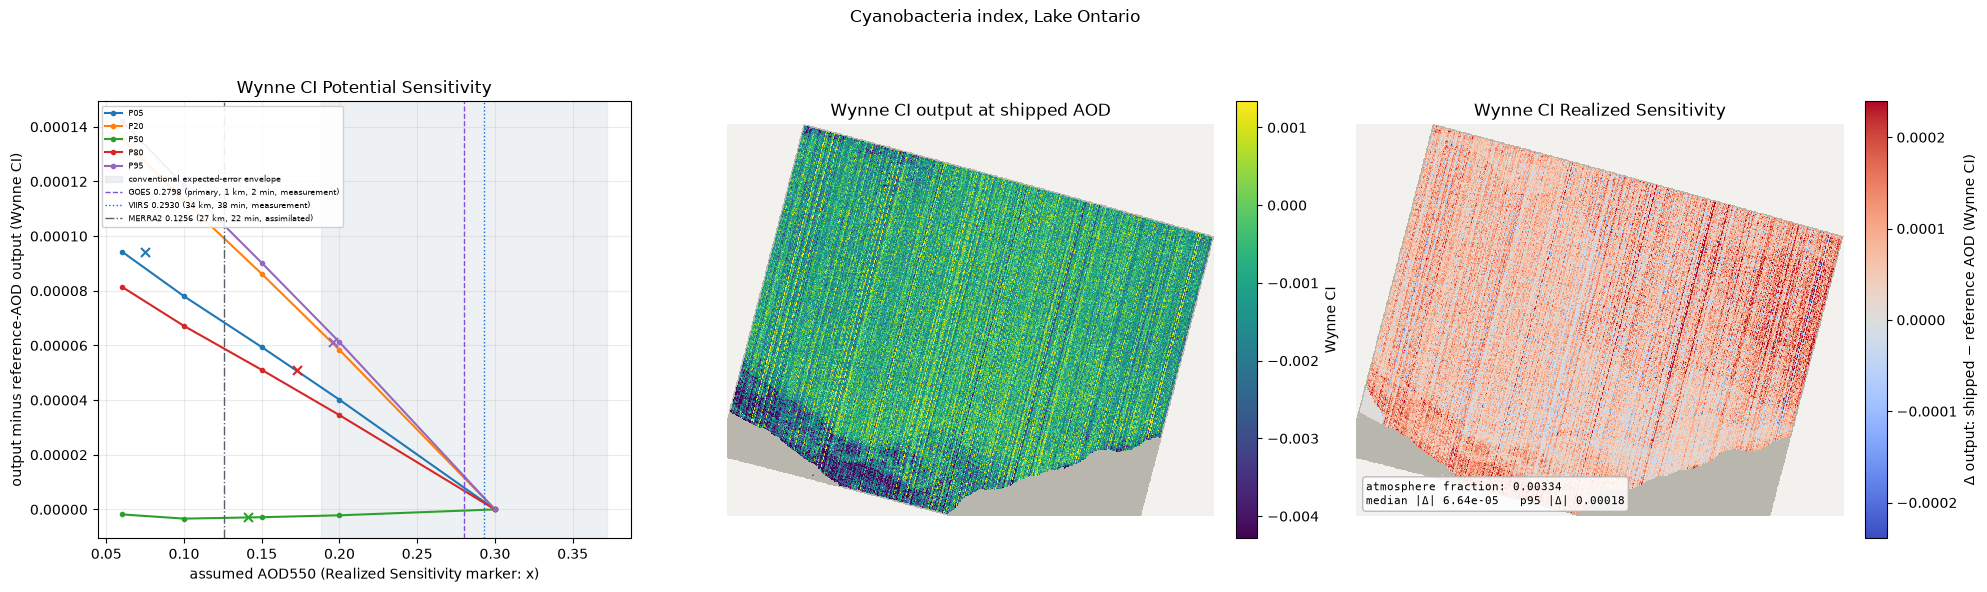

In [11]:
tanager_data.fetch_scene(ci_scene_id, data_dir=DATA_DIR, records=scene_records)
result_ci = sensitivity.run_tanager(
    ci_scene_id, ci_aoi, ci_mask, ci_band_targets_nm,
    ci_reference_aod, ci_aero_profile,
    algorithm=as_algorithm(cyanobacteria_index, result_index=0),
    node_only=True, extra_curve_aod=[v for _s, v, _d in ci_references],
    unit="Wynne CI", algorithm_name="Wynne CI",
    data_dir=DATA_DIR, lut=LUT_STORE_TANAGER,
)
vf_ci = sensitivity.variance_fraction(result_ci.at_reference, result_ci.delta)
print("atmosphere fraction:", vf_ci.atmosphere_fraction,
      "| reliable:", vf_ci.reliable, "| coverage:", vf_ci.coverage)
plotting.sensitivity_figure(result_ci, references=ci_references,
                            unit="Wynne CI", title="Cyanobacteria index, Lake Ontario")
plt.show()

## 8. A spectral inversion on the same kind of water: CDOM off Malibu

The same coastal water, corrected the same way, but a different kind of algorithm. QAA
v6 (Lee et al. 2002, updated 2014) is a full spectral inversion. It reports a
dissolved-and-detrital absorption `a_dg(443)`, a phytoplankton absorption `a_ph(443)`,
and the `a_dg` spectral slope `S`. The slope is a band ratio, so an error that shifts
the whole spectrum largely cancels in it. The two absorption magnitudes do not cancel:
a wrong blue reflectance moves absorption between them. So one inversion produces both
a near-immune output and two of the most AOD-exposed outputs in this walkthrough, and
`a_dg(443)` alone runs far above the near-band index of section 7 on the same scene.
The figure shows `a_dg(443)`, and the run prints all three.

In [12]:
cdom_scene_id = "20250123_185518_92_4001"  # the Malibu scene again, over water
cdom_aoi = (0, 1063, 0, 957)
cdom_aero_profile = "Maritime"
cdom_band_targets_nm = [412.0, 443.0, 490.0, 555.0, 670.0]
cdom_reference_aod = 0.0407                 # AERONET, MISR-JPL, same hour
cdom_references = [
    ("aeronet", 0.0407, "primary, MISR-JPL, 47 km, same hour"),
    ("goes", 0.1000, "3 km, 5 min, measurement"),
    ("merra2", 0.0233, "23 km, 25 min, assimilated"),
    ("viirs", 0.0170, "40 km, 47 min, measurement"),
]
cdom_mask = masks.admissible(cdom_scene_id, cdom_band_targets_nm, masks.tanager_water, data_dir=DATA_DIR)

**The run.** One `run_tanager` call per output, since each is a separate per-pixel
quantity. QAA v6's absorption magnitudes have a `1 / (xi - zeta)` singularity that
throws a handful of pixels to `|value|` around 100 where the denominator crosses zero.
Physical CDOM absorption here is well under 1 per metre, so `a_dg` and `a_ph` are
measured on `|value| < 2`. The slope `S` needs no such guard.

S (slope)   atmosphere fraction: 0.0266  reliable: True
a_dg(443)   atmosphere fraction: 0.5425  reliable: True
a_ph(443)   atmosphere fraction: 0.6391  reliable: True


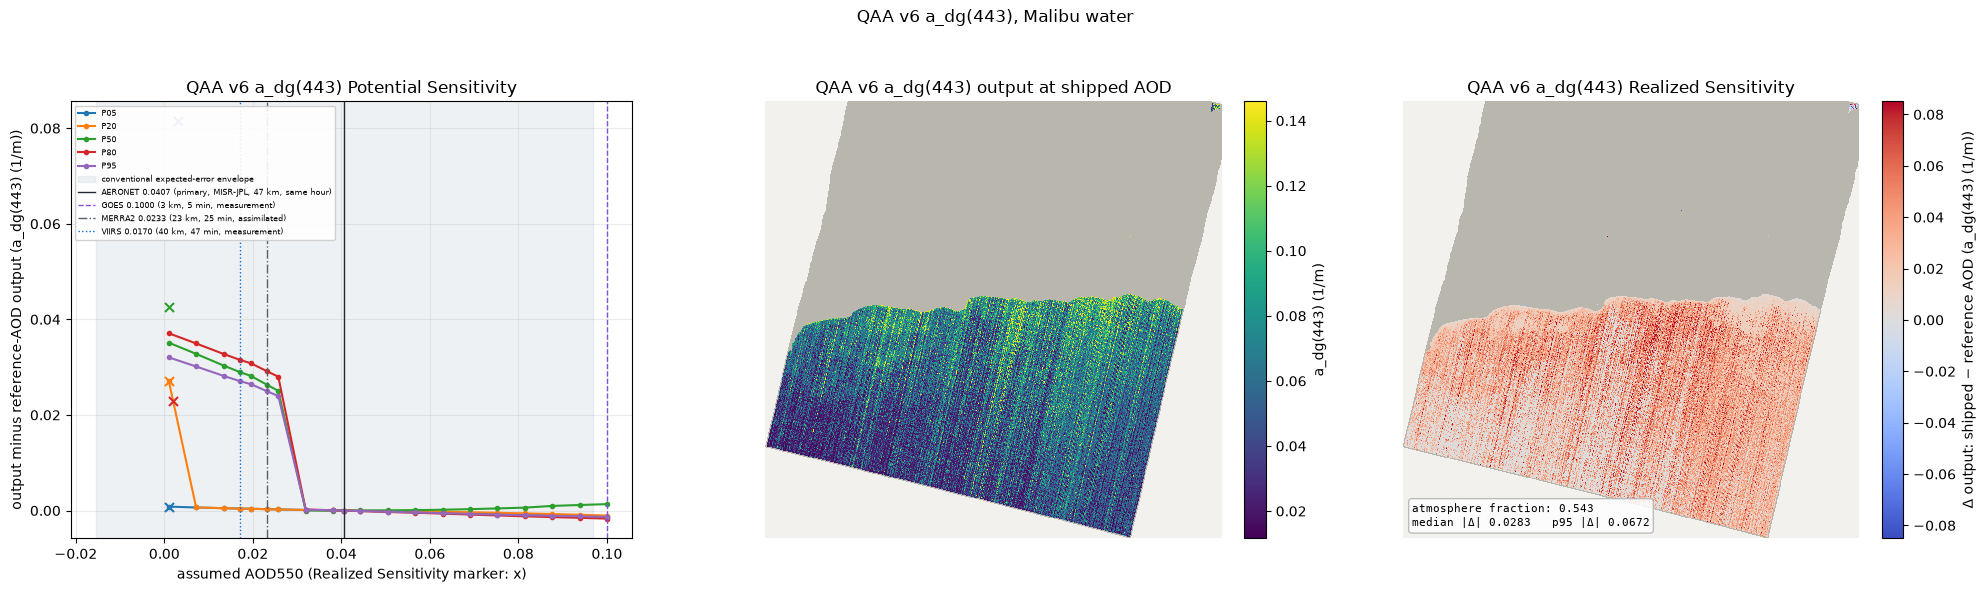

In [13]:
tanager_data.fetch_scene(cdom_scene_id, data_dir=DATA_DIR, records=scene_records)


def _run_cdom(result_index, unit, name, *, physical):
    result = sensitivity.run_tanager(
        cdom_scene_id, cdom_aoi, cdom_mask, cdom_band_targets_nm,
        cdom_reference_aod, cdom_aero_profile,
        algorithm=as_algorithm(cdom_absorption, result_index=result_index),
        extra_curve_aod=[v for _s, v, _d in cdom_references],
        unit=unit, algorithm_name=name,
        data_dir=DATA_DIR, lut=LUT_STORE_TANAGER,
    )
    keep = np.isfinite(result.at_reference) & np.isfinite(result.at_shipped)
    if physical:
        keep &= (np.abs(result.at_reference) < 2.0) & (np.abs(result.at_shipped) < 2.0)
    region = np.zeros(result.shape, dtype=bool)
    region[result.rows[keep], result.cols[keep]] = True
    return result.scored(region)


result_cdom_s = _run_cdom(2, "a_dg slope S", "QAA v6 S", physical=False)
result_cdom = _run_cdom(0, "a_dg(443) (1/m)", "QAA v6 a_dg(443)", physical=True)
result_cdom_aph = _run_cdom(1, "a_ph(443) (1/m)", "QAA v6 a_ph(443)", physical=True)

vf_cdom_s = sensitivity.variance_fraction(result_cdom_s.at_reference, result_cdom_s.delta)
vf_cdom = sensitivity.variance_fraction(result_cdom.at_reference, result_cdom.delta)
vf_cdom_aph = sensitivity.variance_fraction(result_cdom_aph.at_reference, result_cdom_aph.delta)
for label, vf in [("S (slope)", vf_cdom_s), ("a_dg(443)", vf_cdom), ("a_ph(443)", vf_cdom_aph)]:
    print(f"{label:11s} atmosphere fraction: {vf.atmosphere_fraction:.4f}  reliable: {vf.reliable}")

plotting.sensitivity_figure(result_cdom, references=cdom_references,
                            unit="a_dg(443) (1/m)", title="QAA v6 a_dg(443), Malibu water")
plt.show()

## 9. A shortwave-infrared mineral feature: AlOH depth at Cuprite, Nevada

Cuprite is a long-standing spectroscopy calibration site in western Nevada. The
algorithm is the continuum-removed depth of the 2.20 micron aluminum-hydroxide
absorption, a marker of clay and mica minerals. The feature sits deep in the shortwave
infrared where aerosol scattering has little leverage, so the Realized Sensitivity
should be close to zero. This is a Method Notes result, no figure.

In [14]:
aloh_scene_id = "20250222_190237_16_4001"
aloh_aoi = (0, 666, 0, 770)
aloh_aero_profile = "Desert"
aloh_band_targets_nm = [2130.0, 2200.0, 2270.0]   # brackets the 2150 / 2200 / 2250 anchors
aloh_reference_aod = 0.1967                 # GOES, 6.3 km and 2 minutes off
aloh_references = [
    ("goes", 0.1967, "primary, 6.3 km, 2 min, measurement"),
    ("viirs", 0.1580, "52.3 km, 57 min, measurement"),
    ("merra2", 0.0469, "33.9 km, 27 min, assimilated"),
]
aloh_mask = masks.admissible(aloh_scene_id, aloh_band_targets_nm, masks.tanager_clear, data_dir=DATA_DIR)

**The run.** No figure here. The headline is the atmosphere fraction, the same
variance decomposition the water examples report. The run also states the count of
look-up-table gaps (Desert with the relative azimuth at zero has a few 6S-unsolvable
anchor bands).

In [15]:
tanager_data.fetch_scene(aloh_scene_id, data_dir=DATA_DIR, records=scene_records)
result_aloh = sensitivity.run_tanager(
    aloh_scene_id, aloh_aoi, aloh_mask, aloh_band_targets_nm,
    aloh_reference_aod, aloh_aero_profile,
    algorithm=as_algorithm(aloh_2200_depth),
    extra_curve_aod=[v for _s, v, _d in aloh_references],
    unit="AlOH 2200 nm depth", algorithm_name="Cuprite AlOH 2200 nm depth",
    data_dir=DATA_DIR, lut=LUT_STORE_TANAGER,
)
aloh_finite = np.isfinite(result_aloh.at_reference) & np.isfinite(result_aloh.delta)
vf_aloh = sensitivity.variance_fraction(result_aloh.at_reference[aloh_finite],
                                        result_aloh.delta[aloh_finite])
print("atmosphere fraction:", vf_aloh.atmosphere_fraction,
      "| reliable:", vf_aloh.reliable, "| coverage:", vf_aloh.coverage,
      "| look-up-table gaps:", int((~aloh_finite).sum()))

atmoresponse/lut.py:1072: RuntimeWarning: LUT has only CWV=1.0 populated for aerosol 'Desert', holding requested CWV at that level rather than interpolating a missing bracket.
  c, clamped = lookup_spectrum_batch(sun_z, view_z, raa, aero_profile, cwv_g_cm2, ozone,


atmosphere fraction: 2.5692056446504803e-05 | reliable: True | coverage: 0.8649927425028124 | look-up-table gaps: 14480


## 10. Collect the figure-ready values

One JSON so the report and the figure captions cite a single source. Cross-check every
value against the report before release.

In [16]:
figure_values = {
    "package_version": atmoresponse.__version__,
    "rajanpur_rsi_atmosphere_fraction": vf_rsi.atmosphere_fraction,
    "malibu_sam_flip_fraction": sam_flip_fraction,
    "malibu_sam_flip_fraction_inside_perimeter": sam_flip_inside,
    "malibu_sam_flip_fraction_outside_perimeter": sam_flip_outside,
    "wynne_ci_atmosphere_fraction": vf_ci.atmosphere_fraction,
    "malibu_qaa_s_atmosphere_fraction": vf_cdom_s.atmosphere_fraction,
    "malibu_qaa_a_dg_443_atmosphere_fraction": vf_cdom.atmosphere_fraction,
    "malibu_qaa_a_ph_443_atmosphere_fraction": vf_cdom_aph.atmosphere_fraction,
    "cuprite_aloh_atmosphere_fraction": vf_aloh.atmosphere_fraction,
}
print(json.dumps(figure_values, indent=2))
Path("figure_values.json").write_text(json.dumps(figure_values, indent=2) + "\n")

{
  "package_version": "0.1.0",
  "rajanpur_rsi_atmosphere_fraction": 0.09859906661145722,
  "malibu_sam_flip_fraction": 0.04182022544770716,
  "malibu_sam_flip_fraction_inside_perimeter": 0.05891369829240318,
  "malibu_sam_flip_fraction_outside_perimeter": 0.024442870375415465,
  "wynne_ci_atmosphere_fraction": 0.00334371739727399,
  "malibu_qaa_s_atmosphere_fraction": 0.02658444599384764,
  "malibu_qaa_a_dg_443_atmosphere_fraction": 0.5425003819131826,
  "malibu_qaa_a_ph_443_atmosphere_fraction": 0.639116389554559,
  "cuprite_aloh_atmosphere_fraction": 2.5692056446504803e-05
}


586